# Player Similarity - Clustering

This notebook uses K-means clustering to group players according to their goals and assists per 90 minutes.

In [22]:
import pandas as pd

df = pd.read_csv('../data/processed/player_contributions.csv')

forwards_df = df.loc[df['PrimaryPos'] == 'FW'].copy()

X = forwards_df[['Gls90', 'Ast90']].copy()


## Feature scaling

Goals and assists per 90 mins are standardised before clustering.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit(X).transform(X)

## Selecting the number of clusters

Several values of k are evaluated using inertia and silhouette score.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2,9)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )


## Visualising results of elbow method and silhouette method

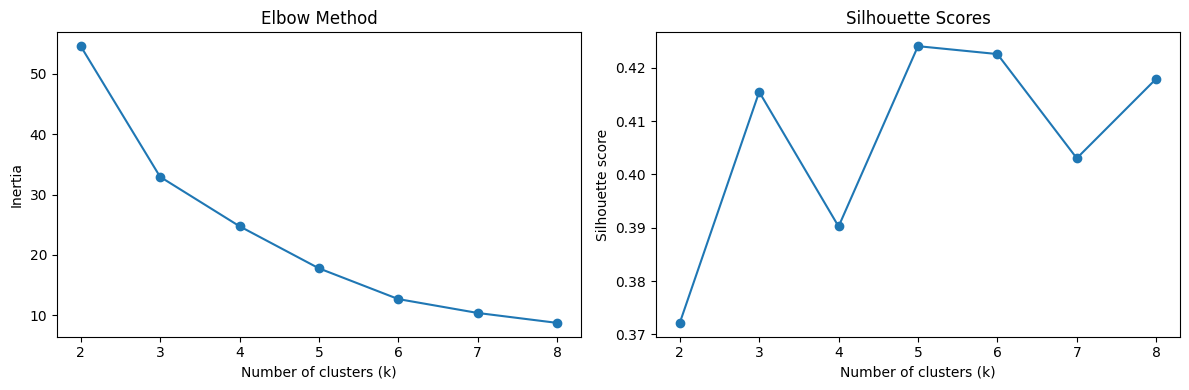

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

## Creating final model and plotting it

In [26]:
final_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10)

cluster_labels = final_model.fit_predict(X_scaled)
forwards_df['Cluster'] = cluster_labels
forwards_df[['Player', 'Gls90', 'Ast90', 'Cluster']].sort_values(['Cluster', 'Gls90'], ascending=[True,False])



,Player,Gls90,Ast90,Cluster
290,Jorgen Strand Larsen,0.30,0.00,0
333,Chris Wood,0.30,0.00,0
285,Dominic Solanke,0.27,0.00,0
188,Noni Madueke,0.22,0.07,0
85,Evanilson,0.20,0.03,0
17,Tolu Arokodare,0.19,0.06,0
218,Rodrigo Muniz,0.09,0.09,0
15,Jhon Arias,0.08,0.00,0
64,Liam Delap,0.08,0.00,0
289,Jorgen Strand Larsen,0.06,0.06,0


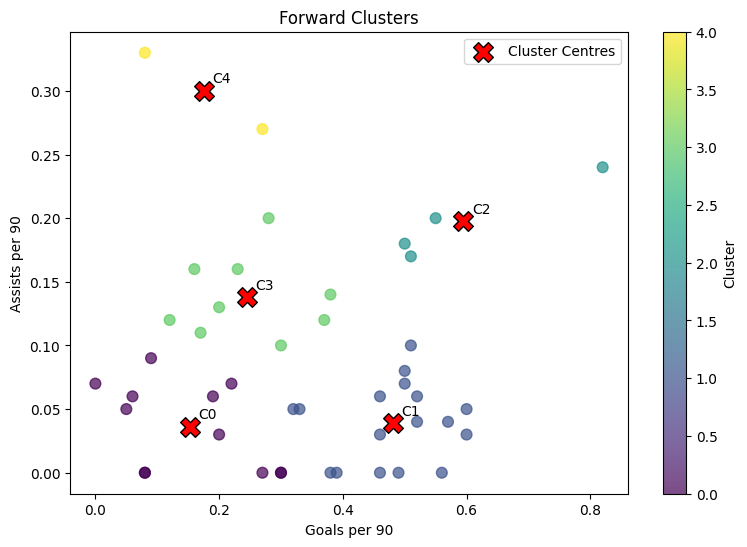

In [29]:
cluster_centres = scaler.inverse_transform(final_model.cluster_centers_)

ax = forwards_df.plot.scatter(
    title='Forward Clusters',
    x='Gls90',
    y='Ast90',
    c='Cluster',
    cmap='viridis',
    colorbar=True,
    figsize=(9, 6),
    alpha=0.7,
    s=60
)

ax.scatter(
    cluster_centres[:, 0],
    cluster_centres[:, 1],
    color='red',
    marker='X',
    s=200,
    edgecolors='black',
    label='Cluster Centres'
    )

for cluster_id, centre in enumerate(cluster_centres):
    ax.annotate(
        f"C{cluster_id}",
        (centre[0], centre[1]),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_xlabel("Goals per 90")
ax.set_ylabel("Assists per 90")
ax.legend()

plt.show()